In [ ]:
import sys
import numpy as np
import random
import pandas as pd

from dataclasses import dataclass
from typing import Tuple, List, Callable, Dict

#import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


from sklearn.preprocessing import OneHotEncoder
from utils_online import path_opt, compute_normalized_future_rewards, reward_simulate,_successors, ForagingConfig, ForagingPlaygroundLinear, EncodeConfig, Encoder


In [23]:
cfg = ForagingConfig(W=7, patch_A=1, patch_B=5, base_reward=10.0,
                     decay_rate=0.6, reward_period=20, gamma=0.5)

env = ForagingPlaygroundLinear(cfg)


In [2]:
#from utils import _successors  # 直接用 utils 里定义的
import math, random
from dataclasses import dataclass
from typing import List, Tuple, Optional
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [3]:
# environment setup
# session_duration = 500000
# env_name = 'ForagingPlaygroundLinear-v0'
# register_custom_env(
#     env_name = env_name, 
#     map_name = 'short',
#     base_reward = 10.0,
#     decay_rate = 0.6,
#     reward_period = 10,
#     session_duration = session_duration
# )
# env = gym.make(env_name)

base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [3]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=6):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df

**Estimator and inference**

In [ ]:
class RewardNet(nn.Module):
    def __init__(self, in_dim:int):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(in_dim,256), nn.ReLU(),
            nn.Linear(256,256), nn.ReLU(),
            nn.Linear(256,1)
        )
    def forward(self,x:torch.Tensor)->torch.Tensor:
        return self.net(x).squeeze(-1)

def successors(x:int, W:int)->List[int]:
    nxt=[x]
    if x>0: nxt.append(x-1)
    if x<W-1: nxt.append(x+1)
    return nxt

@torch.inference_mode()
def plan_openloop_with_model_tree(x0:int, t0:int, H:int, L:int,
                                  model:RewardNet, enc:Encoder, env:ForagingPlaygroundLinear)\
                                  ->Tuple[List[int], float]:
    device = next(model.parameters()).device
    gamma  = env.cfg.gamma
    W      = env.cfg.W
    x_cur, t_cur = x0, t0
    path=[]; surrogate_total=0.0

    for _ in range(H):
        times = [t_cur+i+1 for i in range(L)]
        feat_tbl = enc.encode_table(times)                  # [L, W, dim]
        X = torch.from_numpy(feat_tbl.reshape(L*W, -1)).float().to(device, non_blocking=True)
        rhat = model(X).detach().cpu().numpy().reshape(L, W) 

        # === Tree search ===
        best_score=-1e18; best_first=x_cur
        def dfs(node:int, depth:int, total:float, g:float):
            nonlocal best_score, best_first
            if depth==L: 
                if total>best_score: best_score=total
                return
            for nx in _successors(node):
                r_now = g * float(rhat[depth, nx])
                if depth==0:
                    prev=best_score
                    dfs(nx, depth+1, total+r_now, g*gamma)
                    if best_score>prev: best_first=nx
                else:
                    dfs(nx, depth+1, total+r_now, g*gamma)

        dfs(x_cur, 0, 0.0, 1.0)

        path.append(best_first)
        surrogate_total += float(rhat[0, best_first])      # excute first action
        x_cur, t_cur = best_first, t_cur+1

    return path, surrogate_total 

**Main**

In [ ]:
@dataclass
class TrainConfig:
    total_steps:int=400          
    infer_window:int=20            # H：Length of plan
    plan_L:int=6                   # L：look-ahead 
    lr:float=1e-3
    replay_cap:int=5000
    batch_size:int=128
    warmup:int=200                 
    updates_per_step:int=1         
    log_on_infer:bool=True         #Only print after starting inference
    seed:int=515

class Replay:
    def __init__(self, cap:int):
        self.cap=cap
        self.buf:List[Tuple[np.ndarray,float]]=[]
    def push(self, feat:np.ndarray, r:float):
        self.buf.append((feat.astype(np.float32), float(r)))
        if len(self.buf)>self.cap: self.buf.pop(0)
    def sample(self, n:int)->Tuple[torch.Tensor, torch.Tensor]:
        n=min(n, len(self.buf))
        idx=np.random.choice(len(self.buf), size=n, replace=False)
        X=torch.from_numpy(np.stack([self.buf[i][0] for i in idx], axis=0)).float()
        y=torch.from_numpy(np.array([self.buf[i][1] for i in idx], dtype=np.float32))
        return X,y

def run(seed:int=515):
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    #Config for environment
    fcfg=ForagingConfig(seed=seed)
    enc_cfg=EncodeConfig(fcfg.W, fcfg.reward_period, fourier_K=3)
    tcfg=TrainConfig(seed=seed)
    env=ForagingPlaygroundLinear(fcfg)
    enc=Encoder(enc_cfg)
    net=RewardNet(enc_cfg.dim).to(device)
    opt=optim.Adam(net.parameters(), lr=tcfg.lr)
    loss_fn=nn.MSELoss()
    replay=Replay(cap=tcfg.replay_cap)

    times:List[int]=[]
    norm_regs:List[float]=[]

    def build_rewards_in_period(base_reward: float, decay_rate: float, reward_period: int, total_steps: int):
      rewards_in_period = []
      for period_start in range(0, total_steps, reward_period):
        period_end = min(period_start + reward_period, total_steps)
        steps_in_period = np.arange(period_start, period_end)
        rewards = base_reward * (decay_rate ** (steps_in_period - period_start))
        rewards_in_period.extend(rewards)
      return np.array(rewards_in_period, dtype=float)

    rewards_in_period = build_rewards_in_period(
    fcfg.base_reward, fcfg.decay_rate, fcfg.reward_period,
    total_steps=tcfg.total_steps + tcfg.infer_window + 100)



    # Main Loop
    x, t = env.reset()
    planned_path: List[int] = []   

    for step in range(1, tcfg.total_steps+1):
        just_inferred=False

        if step > tcfg.warmup and not planned_path:
            net.eval()
            with torch.inference_mode():
                path_nn, _ = plan_openloop_with_model_tree(x, t, H=tcfg.infer_window, L=tcfg.plan_L,
                                                      model=net, enc=enc, env=env)
                path_optimal, ireward_opt = path_opt(x, t, tcfg.infer_window,
                               base_reward=fcfg.base_reward,
                               decay_rate=fcfg.decay_rate,
                               reward_period=fcfg.reward_period)

                     
                ireward_nn = [float(reward_simulate(state, t+i+1,
                                    base_reward=fcfg.base_reward,
                                    decay_rate=fcfg.decay_rate,
                                    reward_period=fcfg.reward_period))               for i, state in enumerate(path_nn)]


                ireward_opt = [float(reward_simulate(state, t+i+1,
                                    base_reward=fcfg.base_reward,
                                    decay_rate=fcfg.decay_rate,
                                    reward_period=fcfg.reward_period)) for i, state in enumerate(path_optimal)]
                Y_nn = compute_normalized_future_rewards(ireward_nn, T=tcfg.infer_window, gamma=fcfg.gamma)
                Y_opt = compute_normalized_future_rewards(ireward_opt, T=tcfg.infer_window, gamma=fcfg.gamma)
                risk_nn = - np.sum(Y_nn)
                risk_opt = - np.sum(Y_opt)
                norm_reg = (risk_nn - risk_opt)/(tcfg.infer_window)
                
            times.append(t)              
            norm_regs.append(norm_reg)
            planned_path = path_nn[:]
            just_inferred=True
            if tcfg.log_on_infer:
                overlap = int(np.sum(np.array(path_nn)==np.array(path_opt)))
                print(f"[t={t:>5}] norm_reg(ret/H)={norm_reg:.4f}")
                print(path_optimal[:20])
                print(path_nn[:20])

        if step <= tcfg.warmup:
            # warmup
            nx = random.choice(successors(x, fcfg.W))
        else:
            #online planned path
            nx = planned_path.pop(0)

        a = int(np.clip(nx - x, -1, 1))
        x, r_true, t = env.step(a)

        # === control training start at which timestep===
        feat = enc.encode(x, t)
        replay.push(feat, r_true)
        if len(replay.buf) >= 140:
            for _ in range(tcfg.updates_per_step):
                net.train()
                Xb, yb = replay.sample(tcfg.batch_size)
                Xb = Xb.to(device, non_blocking=True); yb = yb.to(device, non_blocking=True)
                pred = net(Xb); loss = loss_fn(pred, yb)
                opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
                
    return times, norm_regs

Device: cpu
[t=  200] norm_reg(ret/H)=0.2315
[4, 3, 2, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1]
[6, 6, 5, 5, 5, 5, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1]
[t=  220] norm_reg(ret/H)=2.3730
[1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1]
[t=  240] norm_reg(ret/H)=0.0000
[1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1]
[1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1]
[t=  260] norm_reg(ret/H)=0.0000
[1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1]
[1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1]
[t=  280] norm_reg(ret/H)=0.0000
[1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1]
[1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1]
[t=  300] norm_reg(ret/H)=0.0000
[1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1]
[1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1]
[t=  320] norm_reg(ret/H)=0.0000
[1, 1, 1, 1, 1, 1, 2, 3, 

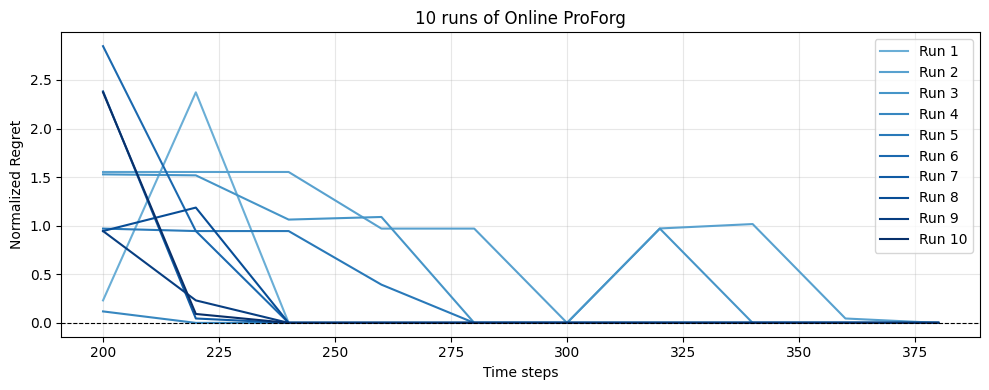

In [28]:
if __name__=="__main__":
    cmap = plt.colormaps.get_cmap("Blues")   # 只传名字
    colors = [cmap(i) for i in np.linspace(0.5, 1.0, 10)]  # 取从浅到深的10个颜色

    plt.figure(figsize=(10,4))

    for rep in range(10):
        times, norm_regs = run(seed=515+rep)
        plt.plot(times, norm_regs, color=colors[rep], alpha=1.0, label=f"Run {rep+1}")

    plt.axhline(0.0, color="k", linestyle="--", linewidth=0.8)
    plt.xlabel("Time steps"); plt.ylabel("Normalized Regret")
    plt.title("10 runs of Online ProForg")
    plt.yticks([0,0.5,1,1.5,2,2.5])
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
